# **Analysis of 1,000 FAERS Drug Adverse Event Reports (2024)**
**Author:** Clifford Elike  
**Date:** 2026  
**Purpose:** Reproducible pipeline: ingest FAERS API data, clean/flatten JSON, perform EDA, compute disproportionality signals (ROR/PRR), and build a proof‑of‑concept predictive model for serious outcomes.   
**Outputs:** `DrugIncidents_cleaned.csv`, figures in `figures/`, `data_dictionary.csv`


## **Libraries**

In [2]:
# Environment setup
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import datetime as dt
import ast

import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, confusion_matrix

import statsmodels.api as sm
import statsmodels.formula.api as smf

# plotting defaults
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (10, 6)})
plt.rcParams["figure.dpi"] = 120

# output directories
Path("g:\\My Drive\\Data Analytics Portfolio\\Drug Adverse Events Project\\figures").mkdir(exist_ok=True)
Path("g:\\My Drive\\Data Analytics Portfolio\\Drug Adverse Events Project\\outputs").mkdir(exist_ok=True) 


## **API Call**

In [ ]:
# Cell: Data ingestion from FAERS API (1000 rows, 2024)
import requests


def get_drug_events(max_records = 25000):
   raw_results = []
   limit = 1000
   skip = 0
   api_key = "api_key"
   
   while skip < max_records:
        endpoint_url = f"https://api.fda.gov/drug/event.json?api_key={api_key}&search=receivedate:[20240101+TO+20241231]+AND+_exists_:patient.patientonsetage+AND+_exists_:patient.patientonsetageunit+AND+_exists_:patient.patientweight+AND+_exists_:patient.drug.drugstartdate+AND+_exists_:patient.drug.drugenddate+AND+_exists_:patient.drug.drugtreatmentduration+AND+_exists_:seriousnessdeath+AND+_exists_:occurcountry&limit={limit}&skip={skip}"

        r = requests.get(endpoint_url)
        r.raise_for_status()
        payload = r.json()
        response = payload.get("results", [])
        raw_results.extend(response)
        skip += limit
   return raw_results

        


In [71]:
raw_result = get_drug_events(max_records=24000)

## **ETL Pipeline**

In [177]:
# Cell: Create DataFrame and flatten nested JSON
df_raw = pd.DataFrame(raw_result)

# Drop columns that are not needed or duplicated
drop_cols = [
    "receivedateformat", "receivedate", "receiptdateformat", "receiptdate",
    "fulfillexpeditecriteria", "sender", "receiver", "seriousnessother",
    "seriousnesscongenitalanomali", "primarysourcecountry", "companynumb",
    "authoritynumb", "transmissiondateformat", "reportduplicate", "duplicate"
]

df_raw = df_raw.drop(columns=[c for c in drop_cols if c in df_raw.columns])

# Flatten patient
if "patient" in df_raw.columns:
    patient_flat = pd.json_normalize(df_raw["patient"])
    # drop large narrative if present
    if "summary.narrativeincludeclinical" in patient_flat.columns:
        patient_flat = patient_flat.drop(columns=["summary.narrativeincludeclinical"])
    #df_raw = pd.concat([df_raw.drop(columns=["patient"]), patient_flat], axis=1)

# Flatten reaction (take first reaction object if list)
if "reaction" in patient_flat.columns:
    reaction_flat = pd.json_normalize(patient_flat["reaction"])
    # reaction_flat may be a column of lists; normalize first element
    if isinstance(reaction_flat.iloc[0][0], (dict, list)):
        reaction_flat = pd.json_normalize(reaction_flat[0])
    # drop MedDRA version column if present
    reaction_flat = reaction_flat.drop(columns=[c for c in ["reactionmeddraversionpt"] if c in reaction_flat.columns])
    #df_raw = pd.concat([df_raw.drop(columns=["reaction"]), reaction_flat], axis=1)

# Flatten primarysource
if "primarysource" in df_raw.columns:
    primary_flat = pd.json_normalize(df_raw["primarysource"])
    if "literaturereference" in primary_flat.columns:
        primary_flat = primary_flat.drop(columns=["literaturereference"])
    #df_raw = pd.concat([df_raw.drop(columns=["primarysource"]), primary_flat], axis=1)

# Flatten drug (take first drug entry)
if "drug" in patient_flat.columns:
    drug_flat = pd.json_normalize(patient_flat["drug"])
    if isinstance(drug_flat.iloc[0][0], (dict, list)):
        drug_flat = pd.json_normalize(drug_flat[0])
    # select relevant drug fields if present
    keep_drug_cols = [
        "drugcharacterization", "medicinalproduct", "drugdosagetext", "drugdosageform",
        "drugadministrationroute", "drugindication", "drugstartdate",
        "actiondrug", "activesubstance.activesubstancename", "openfda.application_number",
        "openfda.brand_name", "openfda.route", "openfda.substance_name", "openfda.pharm_class_moa"
    ]
    keep_drug_cols = [c for c in keep_drug_cols if c in drug_flat.columns]
    #drug_flat = drug_flat[keep_drug_cols]
    #df_raw = pd.concat([df_raw.drop(columns=["drug"]), drug_flat], axis=1)

# Quick shape check
df_raw.shape


(24000, 12)

In [178]:
df_raw = df_raw.drop(["primarysource", "patient"], axis = 1)

In [179]:

# Mapping dictionaries for recoding
mappings = {
    "reporttype": {"1": "Spontaneous", "2": "Report from study", "3": "Other", "4": "Not available to sender"},
    "serious": {"1": "Serious", "2": "Not serious"},
    "seriousnesslifethreatening": {"1": "Life threatening", "2": "Not life threatening"},
    "seriousnessdeath": {"1": "Death", "2": "No death"},
    "seriousnesshospitalization": {"1": "Hospitalization", "2": "No hospitalization"},
    "seriousnessdisabling": {"1": "Disabling", "2": "Not disabling"},
    "patientonsetageunit": {"800": "Decade", "801": "Year", "802": "Month", "803": "Week", "804": "Day", "805": "Hour"},
    "patientagegroup": {"1": "Neonate", "2": "Infant", "3": "Child", "4": "Adolescent", "5": "Adult", "6": "Elderly"},
    "patientsex": {"0": "Unknown", "1": "Male", "2": "Female"},
    "reactionoutcome": {"1": "Recovered", "2": "Recovering", "3": "Not Recovered", "4": "Recovered with sequelae", "5": "Fatal", "6": "Unknown"},
    "qualification": {"1": "Physician", "2": "Pharmacist", "3": "Other health professional", "4": "Lawyer", "5": "Non health professional"}
}

for col, mp in mappings.items():
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].astype(str).map(mp)


In [180]:
# Cell: Type coercion and recoding functions
def set_numeric_dtype(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("int")
    return df

def set_datetime_dtype(df, cols, fmt=None):
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", format=fmt).dt.date
    return df

# Apply date coercion
datetime_cols = ["transmissiondate"]
df_raw = set_datetime_dtype(df_raw, datetime_cols)

# Apply numeric coercion
numeric = ["safetyreportversion"]
df_raw = set_numeric_dtype(df_raw, numeric)

In [181]:

# Create binary flags for seriousness
df_raw["death_flag"] = df_raw["seriousnessdeath"].apply(lambda x: 1 if x == "Death" else 0)
df_raw["hospitalization_flag"] = df_raw["seriousnesshospitalization"].apply(lambda x: 1 if x == "Hospitalization" else 0)
df_raw["life_threat_flag"] = df_raw["seriousnesslifethreatening"].apply(lambda x: 1 if x == "Life threatening" else 0)
df_raw["any_serious"] = df_raw[["death_flag", "hospitalization_flag", "life_threat_flag"]].max(axis=1)


### patient

In [182]:
new_patient = patient_flat.drop(["reaction", "drug"], axis = 1)

In [183]:

# Mapping dictionaries for recoding
mappings = {
    "patientonsetageunit": {"800": "Decade", "801": "Year", "802": "Month", "803": "Week", "804": "Day", "805": "Hour"},
    "patientagegroup": {"1": "Neonate", "2": "Infant", "3": "Child", "4": "Adolescent", "5": "Adult", "6": "Elderly"},
    "patientsex": {"0": pd.NA, "1": "Male", "2": "Female"}
}

for col, mp in mappings.items():
    if col in new_patient.columns:
        new_patient[col] = new_patient[col].astype(str).map(mp)

In [184]:
# age and unit 

 
## standardize patient age to years
ageunit_mapping = {
    "Decade": 10,
    "Month": 12,
    "Week" : 54,
    "Day": 365,
    "Hour": 8760
}

def set_age_yr(df, col, col_unit):
    if col in df.columns and col_unit in df.columns:

        df[col] = df[col].astype("float") # set the cole dtype to float

        # decade to year
        decade_mask = df[col_unit] == "Decade"
        df.loc[decade_mask, col] = df.loc[decade_mask, col] * ageunit_mapping["Decade"]
        df.loc[decade_mask, col_unit] = "Year"

        # month to years
        month_mask = df[col_unit] == "Month"
        df.loc[month_mask, col] = df.loc[month_mask, col]/ageunit_mapping["Month"]
        df.loc[month_mask, col_unit] = "Year"

        # week to years
        week_mask = df[col_unit] == "Week"
        df.loc[week_mask, col] = df.loc[week_mask, col]/ageunit_mapping["Week"]
        df.loc[week_mask, col_unit] = "Year"

        # day to years
        day_mask = df[col_unit] == "Day"
        df.loc[day_mask, col] = df.loc[day_mask, col]/ageunit_mapping["Day"]
        df.loc[day_mask, col_unit] = "Year"

        # hour to years
        hour_mask = df[col_unit] == "Hour"
        df.loc[hour_mask, col] = df.loc[hour_mask, col]/ageunit_mapping["Hour"]
        df.loc[hour_mask, col_unit] = "Year"
    return df

new_patient = set_age_yr(new_patient, "patientonsetage", "patientonsetageunit")


In [185]:
numeric_cols = ["patientonsetage", "patientweight"]
new_patient = set_numeric_dtype(new_patient, numeric_cols)

In [186]:
new_patient.columns

Index(['patientonsetage', 'patientonsetageunit', 'patientagegroup',
       'patientweight', 'patientsex'],
      dtype='object')

In [187]:
patient_cols = [col for col in new_patient.columns if new_patient[col].isna().sum()/len(new_patient)<0.30]

new_patient = new_patient[patient_cols]

In [188]:
new_patient.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   patientonsetage      24000 non-null  int64 
 1   patientonsetageunit  24000 non-null  object
 2   patientweight        24000 non-null  int64 
 3   patientsex           23775 non-null  object
dtypes: int64(2), object(2)
memory usage: 750.1+ KB


In [189]:
df_raw = pd.concat([df_raw, new_patient], axis=1)

In [190]:
df_raw.columns

Index(['safetyreportversion', 'safetyreportid', 'occurcountry',
       'transmissiondate', 'reporttype', 'serious', 'seriousnessdeath',
       'seriousnesslifethreatening', 'seriousnesshospitalization',
       'seriousnessdisabling', 'death_flag', 'hospitalization_flag',
       'life_threat_flag', 'any_serious', 'patientonsetage',
       'patientonsetageunit', 'patientweight', 'patientsex'],
      dtype='object')

### primary

In [191]:
primary_flat

,reportercountry,qualification
0,CN,3
1,US,1
2,US,5
3,GB,1
4,US,5
...,...,...
23995,FR,1
23996,US,2
23997,JP,1
23998,CN,3


In [192]:
new_primary = primary_flat

In [193]:
for col, mp in mappings.items():
    if col in new_primary.columns:
        new_primary[col] = new_primary[col].astype(str).map(mappings["qualification"])

In [194]:
df_raw = pd.concat([df_raw, new_primary], axis=1)


### reaction

In [195]:
reaction_flat

,reactionmeddrapt,reactionoutcome
0,Rash pruritic,2
1,Drug withdrawal syndrome,6
2,Infection,3
3,Asthma,2
4,Hypersensitivity,1
...,...,...
23995,Acute kidney injury,3
23996,Malignant neoplasm progression,6
23997,Death,5
23998,Hypoglycaemic coma,1


In [196]:
new_reaction = reaction_flat


In [197]:
# Mapping dictionaries for recoding
mappings = {    
    "reactionoutcome": {"1": "Recovered", "2": "Recovering", "3": "Not Recovered", "4": "Recovered with sequelae", "5": "Fatal", "6": "Unknown"},
}
new_reaction["reactionoutcome"] = new_reaction["reactionoutcome"].astype(str).map(mappings["reactionoutcome"])

In [198]:
df_raw = pd.concat([df_raw, new_reaction], axis=1)


### drug

In [199]:
cols_musk = ~drug_flat.columns.str.contains("openfda") | drug_flat.columns.str.contains("openfda.brand_name")

drug_cols_selected = drug_flat.columns[cols_musk]
new_drug = drug_flat[drug_cols_selected]

In [200]:
# Standardize drug name: prefer openfda.brand_name if available, else medicinalproduct
def choose_drug_name(row):
    brand = row.get("openfda.brand_name")
    med = row.get("medicinalproduct")
    if isinstance(brand, list) and brand:
        return brand[0]
    if pd.notna(med):
        return med
    return None

if "openfda.brand_name" in new_drug.columns or "medicinalproduct" in new_drug.columns:
   new_drug["drug_name_standard"] = new_drug.apply(choose_drug_name, axis=1)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\1797937861.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drug_name_standard"] = new_drug.apply(choose_drug_name, axis=1)


In [201]:
drug_characterization_map = {
    "1": "suspect",
    "2": "concomitant",
    "3": "interacting"
}

new_drug.loc[:, "drugcharacterization"] = new_drug.loc[:, "drugcharacterization"].map(drug_characterization_map)

In [202]:
actiondrug_map = {
    "1": "drug withdrawn",
    "2": "dose reduced",
    "3": "dose increased",
    "4": "dose not changed",
    "5": pd.NA,
    "6": pd.NA
}

new_drug.loc[:,"actiondrug"] = new_drug.loc[:,"actiondrug"].map(actiondrug_map)

In [203]:
new_drug["drugadditional"] = new_drug["drugadditional"].map({"1":"yes",
                                                             "2":"no",
                                                             "3": pd.NA}).fillna(pd.NA)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\2254425566.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugadditional"] = new_drug["drugadditional"].map({"1":"yes",


In [204]:
# set malformed numbers to NA
new_drug[new_drug["drugtreatmentduration"].str.match(r'^\d+(?:\.\d+){2,}$', na=False)] = pd.NA

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\1295581757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug[new_drug["drugtreatmentduration"].str.match(r'^\d+(?:\.\d+){2,}$', na=False)] = pd.NA


In [205]:
duration_map = { 
    "801": "year",
    "802": "month",
    "803": "week",
    "804": "day",
    "805": "hour",
    "806": "minute"
}

new_drug["drugtreatmentdurationunit"] = new_drug["drugtreatmentdurationunit"].map(duration_map)


C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\535415863.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugtreatmentdurationunit"] = new_drug["drugtreatmentdurationunit"].map(duration_map)


In [206]:
year_mask = new_drug["drugtreatmentdurationunit"] == "year"
month_mask = new_drug["drugtreatmentdurationunit"] == "month"
week_mask = new_drug["drugtreatmentdurationunit"] == "week"
hour_mask = new_drug["drugtreatmentdurationunit"] == "hour"
minute_mask = new_drug["drugtreatmentdurationunit"] == "minute"

In [207]:
new_drug["drugtreatmentduration"] = new_drug["drugtreatmentduration"].astype(float)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\2844334106.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugtreatmentduration"] = new_drug["drugtreatmentduration"].astype(float)


In [208]:
# convert years to days
new_drug.loc[year_mask, "drugtreatmentduration"] = new_drug.loc[year_mask, "drugtreatmentduration"]*365.24

# convert weeks to days
new_drug.loc[week_mask, "drugtreatmentduration"] = new_drug.loc[week_mask, "drugtreatmentduration"]*7

# convert months to days
new_drug.loc[month_mask, "drugtreatmentduration"] = new_drug.loc[month_mask, "drugtreatmentduration"]*30.44

# convert hours to days
new_drug.loc[hour_mask, "drugtreatmentduration"] = new_drug.loc[hour_mask, "drugtreatmentduration"]/24

# convert minutes to days
new_drug.loc[minute_mask, "drugtreatmentduration"] = new_drug.loc[minute_mask, "drugtreatmentduration"]/1440

# set unit to day
new_drug["drugtreatmentdurationunit"] = "day"

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\1907005704.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugtreatmentdurationunit"] = "day"


In [209]:
# select rows with unknown indication at drugindication
unknown_indiciation = new_drug["drugindication"] == "Product used for unknown indication"

# set unknown drug indication to NA
new_drug.loc[unknown_indiciation, "drugindication"] = pd.NA

#### dosage number/unit

In [210]:
new_drug["drugstructuredosageunit"] = new_drug["drugstructuredosageunit"].astype(str)
new_drug["drugstructuredosagenumb"] = new_drug["drugstructuredosagenumb"].notna().astype(int)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\1801718544.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugstructuredosageunit"] = new_drug["drugstructuredosageunit"].astype(str)
C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\1801718544.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugstructuredosagenumb"] = new_drug["drugstructuredosagenumb"].notna().astype(int)


In [211]:
new_drug["drugstructuredosageunit"].apply(type).value_counts()

drugstructuredosageunit
<class 'str'>    24000
Name: count, dtype: int64

In [212]:
new_drug["drugstructuredosagenumb"].apply(type).value_counts()

drugstructuredosagenumb
<class 'int'>    24000
Name: count, dtype: int64

In [213]:
drugstructure_dosageunit_map = {
    "001": "kilograms",
    "002": "grams",
    "003": "milligrams",
    "004": "micrograms"
}
new_drug.loc[:,"drugstructuredosageunit"] = new_drug.loc[:,"drugstructuredosageunit"].map(drugstructure_dosageunit_map)

In [214]:
kilograms_mask = new_drug["drugstructuredosageunit"] == "kilograms"
grams_mask = new_drug["drugstructuredosageunit"] == "grams"
milligrams_mask = new_drug["drugstructuredosageunit"] == "milligrams"
micrograms_mask = new_drug["drugstructuredosageunit"] == "micrograms"


# convert kilograms to grams
new_drug.loc[kilograms_mask, "drugstructuredosagenumb"] = new_drug.loc[kilograms_mask, "drugstructuredosagenumb"]*1000

# grams
new_drug.loc[grams_mask, "drugstructuredosagenumb"] = new_drug.loc[grams_mask, "drugstructuredosagenumb"]*1

# convert milligrams to grams
new_drug.loc[milligrams_mask, "drugstructuredosagenumb"] = new_drug.loc[milligrams_mask, "drugstructuredosagenumb"]/1000

# convert micrograms to grams
new_drug.loc[micrograms_mask, "drugstructuredosagenumb"] = new_drug.loc[micrograms_mask, "drugstructuredosagenumb"]/1000000

# set unit to day
new_drug["drugstructuredosageunit"] = "grams"

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\4163355238.py:14: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.001 0.001 0.001 ... 0.001 0.001 0.001]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  new_drug.loc[milligrams_mask, "drugstructuredosagenumb"] = new_drug.loc[milligrams_mask, "drugstructuredosagenumb"]/1000
C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\4163355238.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugstructuredosageunit"] = "grams"


In [215]:
new_drug

,drugcharacterization,medicinalproduct,drugbatchnumb,drugauthorizationnumb,drugstructuredosagenumb,drugstructuredosageunit,drugseparatedosagenumb,drugintervaldosageunitnumb,drugintervaldosagedefinition,drugdosagetext,...,actiondrug,drugadditional,activesubstance.activesubstancename,openfda.brand_name,drugcumulativedosagenumb,drugcumulativedosageunit,drugdosageform,drugrecurreadministration,drugrecurrence,drug_name_standard
0,suspect,OXALIPLATIN,A327A99,021492,0.001,grams,1,1,804,"170 MG, QD",...,drug withdrawn,yes,OXALIPLATIN,[OXALIPLATIN],NaN,NaN,NaN,NaN,NaN,OXALIPLATIN
1,suspect,OXYCONTIN,unknown,022272,0.001,grams,1,1,804,"10 MILLIGRAM, DAILY",...,<NA>,<NA>,OXYCODONE HYDROCHLORIDE,[OXYCONTIN],7250,003,Prolonged-release tablet,3,NaN,OXYCONTIN
2,suspect,BUPRENORPHINE,Unknown,021306,0.000,grams,NaN,NaN,NaN,10 MCG/HR,...,drug withdrawn,no,BUPRENORPHINE,"[SUBLOCADE, BUPRENORPHINE, BRIXADI, BUTRANS, B...",NaN,NaN,Transdermal patch,3,NaN,SUBLOCADE
3,suspect,RISANKIZUMAB,NaN,761105,0.000,grams,1,NaN,NaN,150 MG;,...,drug withdrawn,yes,RISANKIZUMAB,NaN,NaN,NaN,Injection,3,NaN,RISANKIZUMAB
4,suspect,BUTRANS,Unknown,021306,0.000,grams,1,1,803,"5 MCG/HR, WEEKLY",...,drug withdrawn,yes,BUPRENORPHINE,[BUTRANS],NaN,NaN,Transdermal patch,3,NaN,BUTRANS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,suspect,OCTREOTIDE ACETATE,NaN,19667,1.000,grams,NaN,NaN,NaN,1 DOSAGE FORM,...,drug withdrawn,no,OCTREOTIDE ACETATE,"[BYNFEZIA PEN, OCTREOTIDE, OCTREOTIDE ACETATE,...",NaN,NaN,Solution for injection,NaN,NaN,BYNFEZIA PEN
23996,suspect,OPDIVO,Unknown,125554,0.001,grams,1,2,803,DOSE : OPD: 160MG / YERVOY: 55MG; FREQ : O...,...,drug withdrawn,<NA>,NIVOLUMAB,[OPDIVO],NaN,NaN,Solution for infusion,3,NaN,OPDIVO
23997,suspect,BAVENCIO,Unknown,761049,0.000,grams,NaN,NaN,NaN,NaN,...,<NA>,<NA>,AVELUMAB,[BAVENCIO],NaN,NaN,Solution for infusion,NaN,NaN,BAVENCIO
23998,suspect,INSULIN GLARGINE,DBJL086,206538,0.000,grams,1,1,804,"17 U, QD",...,drug withdrawn,yes,INSULIN GLARGINE,"[INSULIN GLARGINE, LANTUS SOLOSTAR, LANTUS, TO...",NaN,NaN,Solution for injection,NaN,NaN,INSULIN GLARGINE


#### drug route

In [216]:
# inspect the data type and set data type to string

display(new_drug["drugadministrationroute"].apply(type).value_counts())

drugadministrationroute
<class 'str'>      21555
<class 'float'>     2445
Name: count, dtype: int64

In [217]:
new_drug["drugadministrationroute"] = new_drug["drugadministrationroute"].astype(str)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\2177286472.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugadministrationroute"] = new_drug["drugadministrationroute"].astype(str)


In [218]:
route_map = {

    "001": "Auricular",
    "002": "Buccal",
    "003": "Cutaneous",
    "004": "Dental",
    "005": "Endocervical",
    #"006": "Endosinusial",
    "007": "Endotracheal",
    "008": "Epidural",
    #"009": "Extra-amnoitic",
    "010": "Hemodialysis",
    #"011": "Intra corpus cavenosum",
    #"012": "Intra-amnoitic",
    "013": "Intra-arterial",
    "014": "Intra-articular",
    "015": "Intra-uterine",
    #"016": "Intracardiac",
    "017": "Intracavernous",
    "018": "Intracerebral",
    "019": "Intracervical",
    #"020": "Intrcisternal",
    "023": "Intradermal",
    "025": "Intrahepatic",
    "030": "Intramuscular",
    "031": "Intraocular",
    "033": "Intraperitoneal",
    "037": "Intrathecal",
    "040": "Intravenous bolus",
    "041": "Intravenous drip",
    "042": "Intravenous(unspecified)",
    "043": "Intravesical",
    "045": "Nasal",
    "047": "Opthalmic",
    "048": "Oral",
    "049": "Oropharingeal",
    "050": pd.NA,
    "051": "Parenteral",
    "052": "Periarticular",
    "053": "Perineural",
    "054": "Rectal",
    "055": "Respiratory(inhalation)",
    "057": "Sunconjucntival",
    "058": "Subcutaneous",
    "059": "Subdermal",
    "060": "Sublingual",
    "061": "Topical",
    "062": "Transdermal",
    "064": "Transpacental",
    "065": pd.NA,
    "067": "Vaginal"

}

In [219]:
new_drug["drugadministrationroute"]= new_drug["drugadministrationroute"].map(route_map)

C:\Users\cliff\AppData\Local\Temp\ipykernel_20660\2524104653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_drug["drugadministrationroute"]= new_drug["drugadministrationroute"].map(route_map)


#### cleaned drug cols

In [220]:
new_drug.isna().mean()

drugcharacterization                   0.000000
medicinalproduct                       0.000000
drugbatchnumb                          0.549875
drugauthorizationnumb                  0.090708
drugstructuredosagenumb                0.000000
drugstructuredosageunit                0.000000
drugseparatedosagenumb                 0.444292
drugintervaldosageunitnumb             0.502375
drugintervaldosagedefinition           0.502375
drugdosagetext                         0.175250
drugadministrationroute                0.240125
drugindication                         0.111667
drugstartdateformat                    0.056250
drugstartdate                          0.056250
drugenddateformat                      0.155750
drugenddate                            0.155750
drugtreatmentduration                  0.188333
drugtreatmentdurationunit              0.000000
actiondrug                             0.413500
drugadditional                         0.543708
activesubstance.activesubstancename    0

In [221]:
# keeyp columns that have missingness less than 30 percent

#drug_cols = [col for col in new_drug.columns if new_drug[col].isna().sum()/len(new_drug)<0.30]


In [222]:
#drug_cols

In [223]:

bad_cols = ["drugbatchnumb", "drugauthorizationnumb", "drugseparatedosagenumb", "drugintervaldosageunitnumb",
                  "drugintervaldosagedefinition", "drugcumulativedosagenumb", "drugcumulativedosageunit", 
                  "drugrecurreadministration", "drugrecurrence"]

In [224]:
#new_drug = new_drug[drug_cols].drop(["drugauthorizationnumb", "drugstartdateformat",
 #                                    "drugstartdate", "drugenddateformat", "drugenddate"],axis = 1)

In [225]:
new_drug = new_drug.drop(["drugauthorizationnumb", "drugstartdateformat",
                                     "drugstartdate", "drugenddateformat", "drugenddate"],axis = 1)

In [226]:
new_drug.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   drugcharacterization                 24000 non-null  object 
 1   medicinalproduct                     24000 non-null  object 
 2   drugbatchnumb                        10803 non-null  object 
 3   drugstructuredosagenumb              24000 non-null  float64
 4   drugstructuredosageunit              24000 non-null  object 
 5   drugseparatedosagenumb               13337 non-null  object 
 6   drugintervaldosageunitnumb           11943 non-null  object 
 7   drugintervaldosagedefinition         11943 non-null  object 
 8   drugdosagetext                       19794 non-null  object 
 9   drugadministrationroute              18237 non-null  object 
 10  drugindication                       21320 non-null  object 
 11  drugtreatmentduration       

In [227]:
df_raw = pd.concat([df_raw, new_drug], axis=1)


### save cleaned data


In [228]:

# Save an intermediate cleaned copy
df_raw.to_pickle("g:\\My Drive\\Data Analytics Portfolio\\Drug Adverse Events Project\\outputs\\DrugIncidents_intermediate.pkl")
df_raw.shape


(24000, 45)

## **EDA**



**Checks performed**
- Data quality and missingness per column
- Unique counts for key identifiers (drug_name_standard, reactionmeddrapt)
- Distribution of age, sex, weight


In [32]:
# load cleaned data frame
df_cleaned = pd.read_pickle("g:\\My Drive\\Data Analytics Portfolio\\Drug Adverse Events Project\\outputs\\DrugIncidents_intermediate.pkl")

In [33]:
df_cleaned

,safetyreportversion,safetyreportid,occurcountry,transmissiondate,reporttype,serious,seriousnessdeath,seriousnesslifethreatening,seriousnesshospitalization,seriousnessdisabling,...,actiondrug,drugadditional,activesubstance.activesubstancename,openfda.brand_name,drugcumulativedosagenumb,drugcumulativedosageunit,drugdosageform,drugrecurreadministration,drugrecurrence,drug_name_standard
0,1,23353644,CN,2024-04-10,Spontaneous,Serious,No death,Not life threatening,No hospitalization,Not disabling,...,drug withdrawn,yes,OXALIPLATIN,[OXALIPLATIN],NaN,NaN,NaN,NaN,NaN,OXALIPLATIN
1,1,23353671,US,2024-04-10,Spontaneous,Serious,No death,Not life threatening,No hospitalization,Not disabling,...,<NA>,<NA>,OXYCODONE HYDROCHLORIDE,[OXYCONTIN],7250,003,Prolonged-release tablet,3,NaN,OXYCONTIN
2,2,23353676,US,2024-04-10,Spontaneous,Not serious,No death,Not life threatening,No hospitalization,Not disabling,...,drug withdrawn,no,BUPRENORPHINE,"[SUBLOCADE, BUPRENORPHINE, BRIXADI, BUTRANS, B...",NaN,NaN,Transdermal patch,3,NaN,SUBLOCADE
3,2,23353697,GB,2024-04-10,Spontaneous,Serious,No death,Life threatening,Hospitalization,Not disabling,...,drug withdrawn,yes,RISANKIZUMAB,NaN,NaN,NaN,Injection,3,NaN,RISANKIZUMAB
4,1,23353710,US,2024-04-09,Spontaneous,Not serious,No death,Not life threatening,No hospitalization,Not disabling,...,drug withdrawn,yes,BUPRENORPHINE,[BUTRANS],NaN,NaN,Transdermal patch,3,NaN,BUTRANS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,1,23932504,FR,2024-07-16,Spontaneous,Serious,No death,Not life threatening,Hospitalization,Not disabling,...,drug withdrawn,no,OCTREOTIDE ACETATE,"[BYNFEZIA PEN, OCTREOTIDE, OCTREOTIDE ACETATE,...",NaN,NaN,Solution for injection,NaN,NaN,BYNFEZIA PEN
23996,1,23932509,US,2024-07-16,Spontaneous,Serious,No death,Not life threatening,No hospitalization,Not disabling,...,drug withdrawn,<NA>,NIVOLUMAB,[OPDIVO],NaN,NaN,Solution for infusion,3,NaN,OPDIVO
23997,1,23932595,JP,2024-07-16,Spontaneous,Serious,Death,NaN,NaN,NaN,...,<NA>,<NA>,AVELUMAB,[BAVENCIO],NaN,NaN,Solution for infusion,NaN,NaN,BAVENCIO
23998,1,23932596,CN,2024-07-16,Spontaneous,Serious,No death,Not life threatening,Hospitalization,Not disabling,...,drug withdrawn,yes,INSULIN GLARGINE,"[INSULIN GLARGINE, LANTUS SOLOSTAR, LANTUS, TO...",NaN,NaN,Solution for injection,NaN,NaN,INSULIN GLARGINE


In [34]:
# find the number of cases that are unique
unique_safetyreportid = df_cleaned["safetyreportid"].unique()
print(len(unique_safetyreportid))

# group reports by the number of report versions
unique_saftyreportversion = df_cleaned["safetyreportversion"].value_counts().reindex()
display(unique_saftyreportversion)

24000


safetyreportversion
1     16367
2      4165
3      1550
4       775
5       403
6       228
7       166
8       111
9        58
10       52
11       35
13       15
12       13
14       11
18        9
16        8
15        5
20        4
22        4
19        3
21        3
24        3
25        2
47        2
36        1
35        1
23        1
27        1
26        1
37        1
17        1
65        1
Name: count, dtype: int64

In [35]:
unique_saftyreportversion.head(8).sort_values().sum()/24000

np.float64(0.9902083333333334)

In [36]:

# check for columns that have less than 35% missing data 
not_missing_data = list()
for col in df_cleaned.columns:
    if df_cleaned[col].isna().sum()/len(df_cleaned) < 0.30:
        not_missing_data.append(col)

# check the missingness of each column
missing = df_cleaned.isna().mean().sort_values(ascending=False).round(4)

In [37]:
display(not_missing_data)
len(not_missing_data)

['safetyreportversion',
 'safetyreportid',
 'occurcountry',
 'transmissiondate',
 'reporttype',
 'serious',
 'seriousnessdeath',
 'seriousnesslifethreatening',
 'seriousnesshospitalization',
 'seriousnessdisabling',
 'death_flag',
 'hospitalization_flag',
 'life_threat_flag',
 'any_serious',
 'patientonsetage',
 'patientonsetageunit',
 'patientweight',
 'patientsex',
 'reportercountry',
 'qualification',
 'reactionmeddrapt',
 'reactionoutcome',
 'drugcharacterization',
 'medicinalproduct',
 'drugstructuredosagenumb',
 'drugstructuredosageunit',
 'drugdosagetext',
 'drugadministrationroute',
 'drugindication',
 'drugtreatmentduration',
 'drugtreatmentdurationunit',
 'activesubstance.activesubstancename',
 'openfda.brand_name',
 'drugdosageform',
 'drug_name_standard']

35

In [38]:
# inspect the rate of missingness of each column
display(missing)

drugrecurrence                         0.9999
drugrecurreadministration              0.8010
drugcumulativedosageunit               0.7769
drugcumulativedosagenumb               0.7769
drugbatchnumb                          0.5499
drugadditional                         0.5437
drugintervaldosagedefinition           0.5024
drugintervaldosageunitnumb             0.5024
drugseparatedosagenumb                 0.4443
actiondrug                             0.4135
drugdosageform                         0.2732
drugadministrationroute                0.2401
drugtreatmentduration                  0.1883
drugdosagetext                         0.1752
openfda.brand_name                     0.1570
drugindication                         0.1117
patientsex                             0.0094
seriousnessdisabling                   0.0070
seriousnesslifethreatening             0.0050
seriousnesshospitalization             0.0037
reactionoutcome                        0.0009
qualification                     

In [39]:
df_cleaned.dtypes.to_dict()    

{'safetyreportversion': dtype('int64'),
 'safetyreportid': dtype('O'),
 'occurcountry': dtype('O'),
 'transmissiondate': dtype('O'),
 'reporttype': dtype('O'),
 'serious': dtype('O'),
 'seriousnessdeath': dtype('O'),
 'seriousnesslifethreatening': dtype('O'),
 'seriousnesshospitalization': dtype('O'),
 'seriousnessdisabling': dtype('O'),
 'death_flag': dtype('int64'),
 'hospitalization_flag': dtype('int64'),
 'life_threat_flag': dtype('int64'),
 'any_serious': dtype('int64'),
 'patientonsetage': dtype('int64'),
 'patientonsetageunit': dtype('O'),
 'patientweight': dtype('int64'),
 'patientsex': dtype('O'),
 'reportercountry': dtype('O'),
 'qualification': dtype('O'),
 'reactionmeddrapt': dtype('O'),
 'reactionoutcome': dtype('O'),
 'drugcharacterization': dtype('O'),
 'medicinalproduct': dtype('O'),
 'drugbatchnumb': dtype('O'),
 'drugstructuredosagenumb': dtype('float64'),
 'drugstructuredosageunit': dtype('O'),
 'drugseparatedosagenumb': dtype('O'),
 'drugintervaldosageunitnumb': dty

In [40]:
df_cleaned[["patientonsetage", "patientweight"]].dropna().describe()

,patientonsetage,patientweight
count,24000.000000,24000.000000
mean,55.232833,70.158583
std,23.390254,23.580312
min,0.000000,0.000000
25%,40.000000,57.000000
50%,60.000000,68.000000
75%,72.000000,81.000000
max,965.000000,567.000000


### **Aggregated Summaries**



#### Patient

In [41]:

# Basic demographics
demographics = {
    "n_reports": len(df_cleaned),
    "median_age": df_cleaned["patientonsetage"].dropna().median(),
    "mean_age": df_cleaned["patientonsetage"].dropna().mean(),
    "pct_under_18": (df_cleaned["patientonsetage"] < 18).mean(),
    "pct_over_18": (df_cleaned["patientonsetage"] >= 18).mean(),
    "pct_female": (df_cleaned["patientsex"] == "Female").mean(),
    "pct_male": (df_cleaned["patientsex"] == "Male").mean(),
    "pct_death": df_cleaned["death_flag"].mean(),
    "pct_hospitalization": df_cleaned["hospitalization_flag"].mean(),
    "pct_disabling": df_cleaned["seriousnessdisabling"].map({"Not disabling": 0, "Disabling": 1}).mean()
}
demographics = pd.DataFrame({
    "names": demographics.keys(),
    "values": demographics.values()
    })

demographics["values"] = demographics["values"].apply(lambda x: round(x, 2))
demographics

,names,values
0,n_reports,24000.00
1,median_age,60.00
2,mean_age,55.23
3,pct_under_18,0.07
4,pct_over_18,0.93
5,pct_female,0.57
6,pct_male,0.42
7,pct_death,0.08
8,pct_hospitalization,0.41
9,pct_disabling,0.04


In [42]:
# hospitalization and death rates at the sex level

grouped_demographics = {
    "pct_death_sex": df_cleaned.groupby("patientsex")["death_flag"].mean(),
    "pct_hospitalization_sex": df_cleaned.groupby("patientsex")["hospitalization_flag"].mean(),
}

grouped_demographics = pd.DataFrame({
    "pct_death_flag":grouped_demographics["pct_death_sex"].round(2),
    "pct_hospilazation_flag": grouped_demographics["pct_hospitalization_sex"].round(2)}
    )

grouped_demographics

,pct_death_flag,pct_hospilazation_flag
patientsex,,
Female,0.06,0.37
Male,0.11,0.46


In [43]:
# age
age_Q1 = df_cleaned["patientonsetage"].quantile(0.25)
age_Q3 = df_cleaned["patientonsetage"].quantile(0.75)
age_IQR = age_Q3 - age_Q1

age_lower = age_Q1 - 1.5*age_IQR 
age_upper = age_Q3 + 1.5*age_IQR

age_outliers = df_cleaned.loc[(df_cleaned["patientonsetage"]>age_upper) | (df_cleaned["patientonsetage"]<age_lower), "patientonsetage"]

# weight 
weight_Q1 = df_cleaned["patientweight"].quantile(0.25)
weight_Q3 = df_cleaned["patientweight"].quantile(0.75)
weight_IQR = weight_Q3 - weight_Q1

weight_lower = weight_Q1 - 1.5*weight_IQR
weight_upper = weight_Q3 + 1.5*weight_IQR
weight_outliers = df_cleaned.loc[(df_cleaned["patientweight"]>weight_upper) | (df_cleaned["patientweight"]<weight_lower), "patientweight"]


In [44]:
age = df_cleaned.loc[(df_cleaned["patientonsetage"]>age_lower) & (df_cleaned["patientonsetage"]<age_upper), "patientonsetage"]

weight = df_cleaned.loc[(df_cleaned["patientweight"]>weight_lower) & (df_cleaned["patientweight"]<weight_upper), "patientweight"]

In [45]:
age.describe().round(2)

count    23997.00
mean        55.15
std         21.89
min          0.00
25%         40.00
50%         60.00
75%         72.00
max        104.00
Name: patientonsetage, dtype: float64

In [46]:
weight.describe().round(2)

count    22559.00
mean        69.63
std         17.24
min         22.00
25%         58.00
50%         68.00
75%         80.00
max        116.00
Name: patientweight, dtype: float64

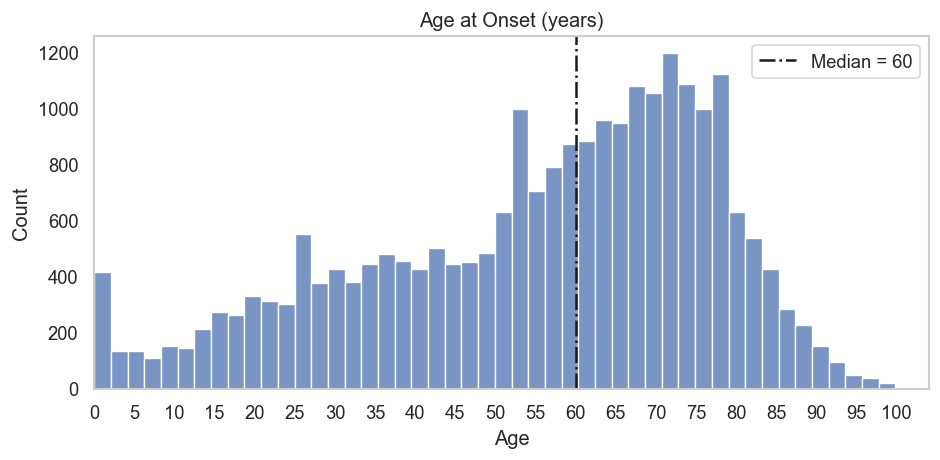

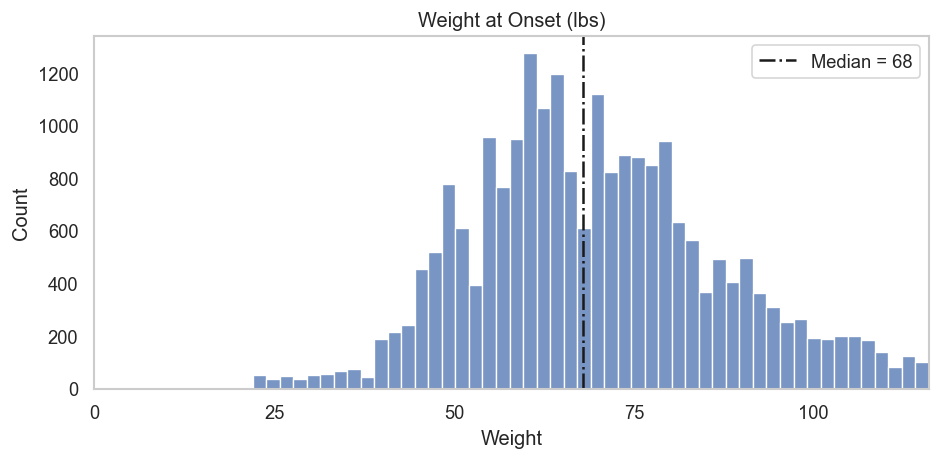

In [47]:
# Age distribution
plt.figure(figsize=(8,4))
sns.histplot(age.dropna(), bins=50, kde=False, color="C0")
median_age = age.median()
plt.axvline(median_age, color="k", linestyle = "dashdot", label=f"Median = {median_age:.0f}")
plt.xlim(age.min(), age.max())
plt.xticks(range(0, age.max(), 5))
plt.title("Age at Onset (years)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.grid(visible=False)
#plt.savefig("figures/age_distribution.png")
plt.show()

# weight distribution
plt.figure(figsize=(8,4))
sns.histplot(weight.dropna(), bins=50, kde=False, color="C0")
median_weight = weight.median()
plt.axvline(median_weight, color="k", linestyle = "dashdot", label=f"Median = {median_weight:.0f}")
plt.xlim(weight.min(), weight.max())
plt.xticks(range(0, weight.max(), 25))
plt.title("Weight at Onset (lbs)")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.grid(visible=False)
#plt.savefig("figures/age_distribution.png")
plt.show()

#### Drug

In [55]:
# 1: suspect 2: concomitant 3: interacting
drug_characterization = {
    "suspect":(df_cleaned["drugcharacterization"]=="suspect").mean(),
    "concomitant": (df_cleaned["drugcharacterization"]=="concomitant").mean(),
    "interacting": (df_cleaned["drugcharacterization"]=="interacting").mean()
}

drug_characterization = pd.DataFrame({
    "type": drug_characterization.keys(),
    "pct": drug_characterization.values()
})

drug_characterization

,type,pct
0,suspect,0.987250
1,concomitant,0.001875
2,interacting,0.010875


In [56]:
# treatment duration

summary_treatment_duration = df_cleaned["drugtreatmentduration"].describe().round(2)

summary_treatment_duration


count    19480.00
mean       138.13
std        554.57
min          0.00
25%          1.00
50%          6.00
75%         50.00
max      13912.00
Name: drugtreatmentduration, dtype: float64

**Drug Routes**

In [57]:
drug_route_count = df_cleaned["drugadministrationroute"].value_counts()
display(len(drug_route_count))
display(drug_route_count)

41

drugadministrationroute
Oral                        8258
Intravenous(unspecified)    4113
Intravenous drip            1691
Subcutaneous                1663
Intra-uterine               1389
Intramuscular                264
Intravenous bolus            169
Transpacental                102
Topical                       76
Opthalmic                     75
Subdermal                     54
Respiratory(inhalation)       47
Intrathecal                   44
Nasal                         43
Transdermal                   42
Cutaneous                     40
Intraocular                   37
Vaginal                       32
Buccal                        17
Parenteral                    15
Intraperitoneal               12
Intra-articular                9
Intra-arterial                 9
Intradermal                    5
Sublingual                     5
Epidural                       4
Intracavernous                 3
Rectal                         3
Auricular                      3
Dental             

In [58]:

# Key value counts
top_drugs = df_cleaned["drug_name_standard"].value_counts()
top_reactions = df_cleaned["reactionmeddrapt"].value_counts()
top_drugindications = df_cleaned["drugindication"].value_counts()

print(len(top_drugs))
print(len(top_drugindications))
print(len(top_reactions))

display(top_drugs.head(20))
display(top_reactions.head(20))
display(top_drugindications.head(20))


1702
1911
2716


drug_name_standard
PARAGARD T 380A                    1321
PAXLOVID                            630
CARBOPLATIN                         626
CYCLOPHOSPHAMIDE                    378
ATORVASTATIN                        337
DUPIXENT                            331
KEYTRUDA                            323
METHOTREXATE                        285
OXALIPLATIN                         271
ABRAXANE                            260
DEFINITY                            250
LENVIMA                             245
IBUPROFEN                           243
AMAZON BASIC CARE ACETAMINOPHEN     242
PLAN B ONE-STEP                     203
CYTARABINE                          202
CABOMETYX                           190
AMOXICILLIN                         182
OPDIVO                              163
SDAMLO                              159
Name: count, dtype: int64

reactionmeddrapt
Complication of device insertion                         895
Myelosuppression                                         482
COVID-19                                                 399
Acute kidney injury                                      292
Neutropenia                                              264
Death                                                    260
Hepatic cytolysis                                        240
Rash                                                     208
Pneumonia                                                186
Dyspnoea                                                 177
Diarrhoea                                                168
Nausea                                                   156
Thrombocytopenia                                         149
Anaphylactic shock                                       146
Pancytopenia                                             145
Interstitial lung disease                                142
Hepatic

drugindication
Contraception                    1083
Plasma cell myeloma               641
COVID-19 treatment                632
Breast cancer                     503
Ill-defined disorder              408
Depression                        315
Hypertension                      303
Rheumatoid arthritis              295
Post coital contraception         241
Type 2 diabetes mellitus          227
Non-small cell lung cancer        214
Echocardiogram                    198
Pain                              198
Diffuse large B-cell lymphoma     195
Acute myeloid leukaemia           184
Dermatitis atopic                 183
Triple negative breast cancer     165
Lung neoplasm malignant           159
Pneumonia                         158
Hepatocellular carcinoma          157
Name: count, dtype: int64

C:\Users\cliff\AppData\Local\Temp\ipykernel_20744\69583316.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped)


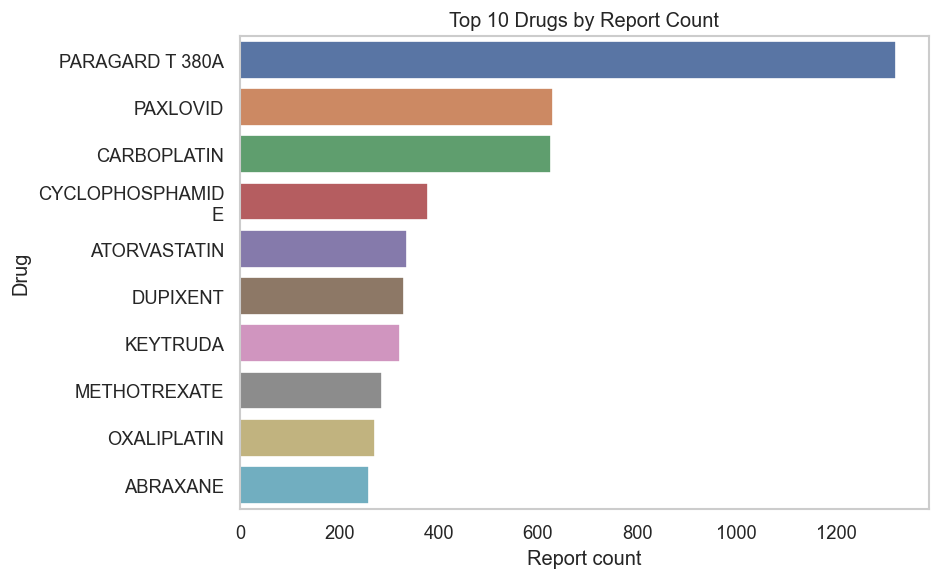

C:\Users\cliff\AppData\Local\Temp\ipykernel_20744\69583316.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(wrapped)


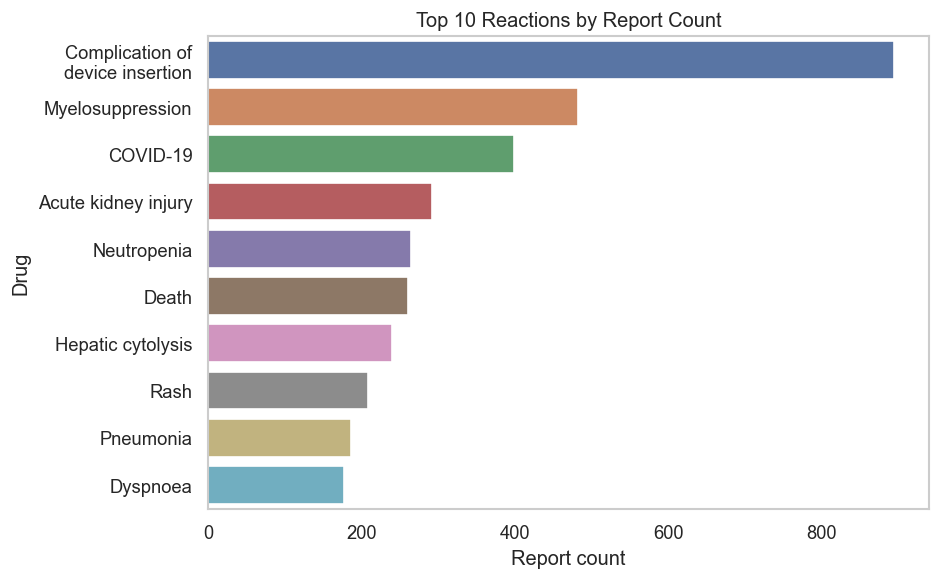

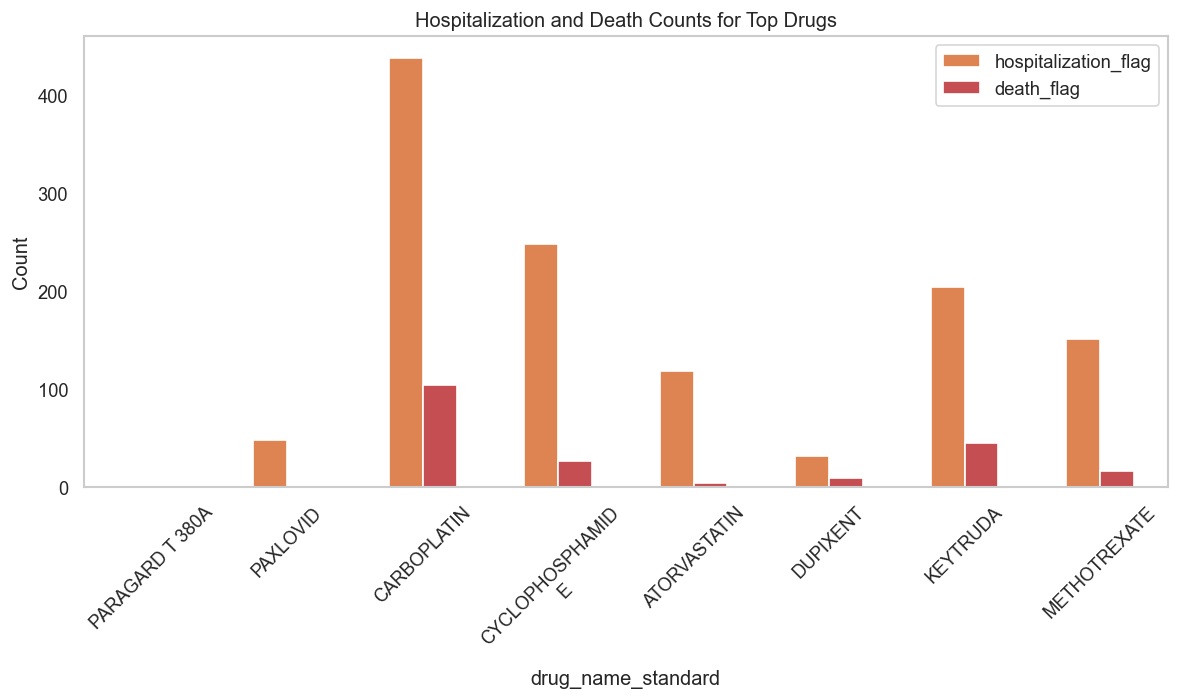

In [59]:


# Top 10 drugs by report count
top10 = top_drugs.head(10)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(y=top10.index, x=top10.values, hue= top10.index, legend=False)
wrapped = [textwrap.fill(l.get_text(), 15) for l in ax.get_yticklabels()]
ax.set_yticklabels(wrapped)
ax.set_xlabel("Report count")
ax.set_ylabel("Drug")
ax.set_title("Top 10 Drugs by Report Count")
plt.tight_layout()
plt.grid(visible=False)
#plt.savefig("figures/top10_drugs.png")
plt.show()


# Top 10 reactions by report count
top10 = top_reactions.head(10)
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(y=top10.index, x=top10.values, hue= top10.index, legend=False)
wrapped = [textwrap.fill(l.get_text(), 20) for l in ax.get_yticklabels()]
ax.set_yticklabels(wrapped)
ax.set_xlabel("Report count")
ax.set_ylabel("Drug")
ax.set_title("Top 10 Reactions by Report Count")
plt.tight_layout()
plt.grid(visible=False)
#plt.savefig("figures/top10_drugs.png")
plt.show()


# Outcome stacked bar for top drugs
top_drug_list = top_drugs.head(8).index.tolist()
df_top = df_cleaned[df_cleaned["drug_name_standard"].isin(top_drug_list)]
outcome_counts = df_top.groupby("drug_name_standard")[["hospitalization_flag", "death_flag"]].sum().loc[top_drug_list]
fig, ax = plt.subplots()
outcome_counts.plot(kind="bar", stacked=False, color=["C1","C3"], ax = ax)
wrapped = [textwrap.fill(l.get_text(), 15) for l in ax.get_xticklabels()]
ax.set_xticklabels(labels=wrapped, rotation = 45)
plt.title("Hospitalization and Death Counts for Top Drugs")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(visible=False)
#plt.savefig("figures/outcome_by_top_drugs.png")
plt.show()


## **PDA**

### Signial Detection



**Definitions**
- **Reporting Odds Ratio (ROR):** compares odds of a specific outcome for reports mentioning a drug vs reports not mentioning the drug.
- **Proportional Reporting Ratio (PRR):** compares proportion of reports with a specific outcome among reports mentioning the drug vs all other reports.

Compute ROR and PRR for `death_flag` and `hospitalization_flag` for the top N drugs.

In [62]:
# Cell: Functions to compute ROR and PRR
def compute_disproportionality(df, drug_col="drug_name_standard", outcome_col="death_flag", min_reports=5):
    """
    Returns a DataFrame with counts, PRR, ROR, and 95% CI for top drugs.
    """
    # contingency table components for each drug
    results = []
    total_reports = len(df)
    total_outcome = df[outcome_col].sum()
    for drug, group in df.groupby(drug_col):
        n_drug = len(group)
        if n_drug < min_reports:
            continue
        a = group[outcome_col].sum()  # outcome with drug
        b = n_drug - a               # no outcome with drug
        c = total_outcome - a        # outcome without drug
        d = (total_reports - n_drug) - c  # no outcome without drug
        # Proportional Reporting Ratio PRR
        prr = (a / n_drug) / (c / (total_reports - n_drug)) if (n_drug>0 and (total_reports - n_drug)>0 and c>0) else np.nan
        # Reporting Odds Ratio ROR
        ror = (a / b) / (c / d) if (b>0 and d>0 and c>0) else np.nan
        # Signal
        if np.isnan(ror):
            signal = np.nan
        elif ror > 2:
            signal = "yes"
        else:
            signal = "no"
        # approximate 95% CI for log(ROR)
        if all(x>0 for x in [a,b,c,d]):
            se_log_ror = np.sqrt(1/a + 1/b + 1/c + 1/d)
            ci_low = np.exp(np.log(ror) - 1.96*se_log_ror)
            ci_high = np.exp(np.log(ror) + 1.96*se_log_ror)
        else:
            ci_low, ci_high = (np.nan, np.nan)
        results.append({
            "drug": drug, 
            "n_reports": n_drug, 
            #"n_death": group[group[outcome_col] == 1][outcome_col].sum(),
            "a_DE": a, 
            "b_De": b, 
            "c_dE": c, 
            "d_de": d,
            "PRR": prr, 
            "ROR": ror, 
            "ROR_CI_low": ci_low, 
            "ROR_CI_high": ci_high,
            "Signal_DR": signal
        })
    res_df = pd.DataFrame(results).sort_values("ROR", ascending=False)
    return res_df

# Compute for death_flag and hospitalization_flag
ror_death = compute_disproportionality(df_cleaned, outcome_col="death_flag", min_reports=50)
#ror_death.head(10).to_csv("outputs/ror_death_top10.csv", index=False)
print(ror_death.shape)
ror_death.head(10)

ror_hospitalization = compute_disproportionality(df_cleaned, outcome_col="hospitalization_flag", min_reports=50)
print(ror_hospitalization.shape)
ror_hospitalization.head(10)

(97, 11)
(97, 11)


,drug,n_reports,a_DE,b_De,c_dE,d_de,PRR,ROR,ROR_CI_low,ROR_CI_high,Signal_DR
9,BORTEZOMIB,85,68,17,9762,14153,1.959844,5.799221,3.406273,9.873244,yes
54,LENALIDOMIDE,130,98,32,9732,14138,1.848984,4.448996,2.982562,6.636428,yes
55,LENVIMA,245,182,63,9648,14107,1.829039,4.224042,3.168059,5.632007,yes
7,AXTLE,153,112,41,9718,14129,1.796319,3.971629,2.774520,5.685250,yes
12,CARBOPLATIN,626,438,188,9392,13982,1.741305,3.468386,2.917731,4.122965,yes
57,LETROZOLE,79,55,24,9775,14146,1.703720,3.316411,2.051759,5.360563,yes
71,PANTOPRAZOLE SODIUM,105,72,33,9758,14137,1.679150,3.160931,2.091813,4.776471,yes
11,CAPECITABINE,107,72,35,9758,14135,1.647626,2.979885,1.988113,4.466402,yes
23,DARZALEX,100,67,33,9763,14137,1.640172,2.939915,1.936246,4.463846,yes
22,DAPTOMYCIN,56,37,19,9793,14151,1.615454,2.813970,1.617383,4.895829,yes


In [111]:
ROR_2_drugs = ror_death.sort_values(by = "ROR", ascending=False).loc[ror_death["ROR"]>= 2]
list_drugs =ror_death.sort_values(by = "ROR", ascending=False).loc[ror_death["ROR"]>= 2]["drug"].tolist()

print(ROR_2_drugs.shape)
print(len(list_drugs))

display(ROR_2_drugs[["drug", "ROR", "ROR_CI_low", "ROR_CI_high"]])
display(list_drugs)

(19, 11)
19


,drug,ROR,ROR_CI_low,ROR_CI_high
89,TECENTRIQ,13.503053,7.935999,22.975359
37,EPKINLY,10.139501,6.646622,15.467928
50,IMBRUVICA,7.667922,4.427579,13.279725
33,ENHERTU,6.824176,4.523790,10.294328
66,OFEV,4.502444,2.482583,8.165692
96,YERVOY,4.075960,2.479241,6.701024
4,APIXABAN,3.817491,2.088185,6.978900
10,CABOMETYX,3.658683,2.602933,5.142647
92,VENCLEXTA,3.405512,2.197816,5.276835
87,SPRAVATO,3.214132,1.649268,6.263773


['TECENTRIQ',
 'EPKINLY',
 'IMBRUVICA',
 'ENHERTU',
 'OFEV',
 'YERVOY',
 'APIXABAN',
 'CABOMETYX',
 'VENCLEXTA',
 'SPRAVATO',
 'AVASTIN',
 'RITUXAN',
 'CARBOPLATIN',
 'DICLOFENAC SODIUM',
 'ELIQUIS',
 'DOCETAXEL',
 'OPDIVO',
 'DEXAMETHASONE',
 'ALLOPURINOL']

### Death Flag Prediction Model

**Goal:** Predict `death_flag` using patient demographics and top drug indicators.  
**Notes:** This is a demonstration model; FAERS is a spontaneous reporting system with strong reporting bias. Model is not for clinical use.


In [63]:
# Prepare modeling dataset
model_df = pd.DataFrame() #df_cleaned.copy()

# Select features: age, sex, weight, top drug indicators (one-hot for top 20 drugs), and patientagegroup
model_df["death_flag"] = df_cleaned["death_flag"]
model_df["age"] = df_cleaned["patientonsetage"]
model_df["sex"] = df_cleaned["patientsex"].replace({"Unknown": np.nan})
model_df["weight"] = df_cleaned["patientweight"]
model_df["drug"] = df_cleaned["drug_name_standard"]
model_df["drug_route"] = df_cleaned["drugadministrationroute"]
model_df["drug_dosage_grams"] = df_cleaned["drugstructuredosagenumb"]
model_df["drug_treatmentduration_days"] = df_cleaned["drugtreatmentduration"].round(3)

features = ["death_flag", "age", "sex", "weight", "drug_route", "drug_dosage", "drug_treatmentduration_days"]


In [112]:
results = []
classification_r = {}
confusion_m = {}


drug_df_sets = {}

for drug in model_df["drug"].unique():
    if drug in list_drugs:
        df_drug = model_df[model_df["drug"] == drug].dropna()

        if len(df_drug) < 50:
            continue
        if len(df_drug["death_flag"].value_counts().index) < 2:
            continue

        X = df_drug[["death_flag", "age", "sex", "weight", "drug_route", "drug_dosage_grams", "drug_treatmentduration_days"]].drop(columns = ["death_flag"])
        y = df_drug["death_flag"]
        
        routes = sorted(df_drug["drug_route"].value_counts().index)
        if len(routes) >= 2:
            referece_route = routes[0]
            X = pd.get_dummies(X, 
                            columns=["sex", "drug_route"],
                            dtype = "int", 
                            drop_first = True)
        else:
            pass
        if len(routes) < 2:
            referece_route = routes[0]
            X = pd.get_dummies(X.drop("drug_route", axis=1),
                            columns = ["sex"],
                            dtype = "int",
                            drop_first = True)
        
        drug_df_sets[drug] = [X, y]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=99)
        
        drug_df_sets[drug].append([X_test, y_test, X_train, y_train])
        
        # Pipeline with scaling and logistic regression (L2)
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, class_weight = "balanced", solver="liblinear"))
            ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test, y_pred_proba)

        classification_r[drug] = classification_report(y_test, y_pred, output_dict=True)
        
        confusion_m[drug] = confusion_matrix(y_test, y_pred, labels= [1, 0])

        features = X_test.columns
        coef = model.named_steps["clf"].coef_[0]
        odds_ratio = np.exp(coef)

        for feature, coef , odds_ratio, in zip(features, coef, odds_ratio):
            results.append({
                "drug": drug,
                "n_reports": len(df_drug),
                "n_test": len(X_test),
                "reference_route": referece_route,
                "feature": feature,
                "coef": coef,
                "odds_r": np.exp(odds_ratio),
                "intercept": np.exp(model.named_steps["clf"].intercept_[0]),
                "auc": auc
                })
            results_df = pd.DataFrame(results)
        
        results_df_wide = results_df.pivot_table(
        index=["drug","intercept",  "reference_route"],
        columns="feature",
        values="odds_r"
        ).reset_index()

In [113]:
results_df

,drug,n_reports,n_test,reference_route,feature,coef,odds_r,intercept,auc
0,CABOMETYX,125,25,Intravenous(unspecified),age,-0.622932,1.709788,0.764001,0.515152
1,CABOMETYX,125,25,Intravenous(unspecified),weight,0.072866,2.931711,0.764001,0.515152
2,CABOMETYX,125,25,Intravenous(unspecified),drug_dosage_grams,0.823971,9.772115,0.764001,0.515152
3,CABOMETYX,125,25,Intravenous(unspecified),drug_treatmentduration_days,-0.254320,2.171555,0.764001,0.515152
4,CABOMETYX,125,25,Intravenous(unspecified),sex_Male,-0.104152,2.462282,0.764001,0.515152
5,CABOMETYX,125,25,Intravenous(unspecified),drug_route_Oral,0.030786,2.804610,0.764001,0.515152
6,VENCLEXTA,83,17,Oral,age,0.992129,14.834705,0.611246,0.714286
7,VENCLEXTA,83,17,Oral,weight,0.661715,6.945634,0.611246,0.714286
8,VENCLEXTA,83,17,Oral,drug_dosage_grams,0.274412,3.727570,0.611246,0.714286
9,VENCLEXTA,83,17,Oral,drug_treatmentduration_days,-0.081750,2.513063,0.611246,0.714286


In [66]:
confusion_m

{'CABOMETYX': array([[ 1,  2],
        [ 9, 13]]),
 'VENCLEXTA': array([[2, 1],
        [7, 7]]),
 'EPKINLY': array([[3, 3],
        [7, 2]]),
 'OPDIVO': array([[ 2,  2],
        [ 8, 15]]),
 'ENHERTU': array([[3, 2],
        [7, 3]]),
 'CARBOPLATIN': array([[ 9,  3],
        [22, 32]]),
 'ELIQUIS': array([[3, 0],
        [3, 7]]),
 'YERVOY': array([[2, 1],
        [5, 5]]),
 'IMBRUVICA': array([[0, 4],
        [6, 0]]),
 'DOCETAXEL': array([[1, 2],
        [9, 5]])}

In [109]:
print(results_df_wide.shape)
results_df_wide

(10, 12)


feature,drug,intercept,reference_route,age,drug_dosage_grams,drug_route_Intravenous drip,drug_route_Intravenous(unspecified),drug_route_Oral,drug_route_Transpacental,drug_treatmentduration_days,sex_Male,weight
0,CABOMETYX,0.764001,Intravenous(unspecified),1.709788,9.772115,NaN,NaN,2.80461,NaN,2.171555,2.462282,2.931711
1,CARBOPLATIN,0.518636,Intravenous drip,8.482162,2.570162,NaN,5.109838,NaN,NaN,1.317827,2.654842,1.578858
2,DOCETAXEL,0.898415,Intravenous bolus,3.637990,2.534621,1.559547,1.667833,NaN,NaN,1.957846,2.939833,2.903264
3,ELIQUIS,0.451744,Oral,3.604780,6.424825,NaN,NaN,NaN,2.718282,1.432706,71.363837,3.612184
4,ENHERTU,0.902672,Intravenous drip,5.778723,5.133345,NaN,2.506416,NaN,NaN,2.875759,2.488926,2.487885
5,EPKINLY,0.968877,Subcutaneous,4.489580,2.718282,NaN,NaN,NaN,NaN,2.718282,2.513416,2.110319
6,IMBRUVICA,0.943140,Oral,4.046887,2.117444,NaN,NaN,NaN,NaN,2.250492,6.710279,4.053207
7,OPDIVO,0.792267,Intravenous drip,5.497103,3.695605,NaN,2.609078,NaN,NaN,2.596086,5.735347,2.085151
8,VENCLEXTA,0.611246,Oral,14.834705,3.727570,NaN,NaN,NaN,NaN,2.513063,3.652089,6.945634
9,YERVOY,0.782341,Intramuscular,2.264261,1.456597,2.883271,4.687464,NaN,NaN,3.029494,2.369696,2.002650


In [108]:
results_df_wide[results_df_wide["drug"] == "CARBOPLATIN"]

feature,drug,intercept,reference_route,age,drug_dosage_grams,drug_route_Intravenous drip,drug_route_Intravenous(unspecified),drug_route_Oral,drug_route_Transpacental,drug_treatmentduration_days,sex_Male,weight
1,CARBOPLATIN,0.518636,Intravenous drip,8.482162,2.570162,NaN,5.109838,NaN,NaN,1.317827,2.654842,1.578858
